# Fraud Detection (Bank Dataset) — EDA & Preprocessing

**Scope of this notebook:** data understanding, exploratory data analysis, and preprocessing **only**.
No model is trained, tuned, or evaluated here. This notebook produces the *model-ready* files consumed by
later modelling notebooks:

| Task        | Output files under `data/processed/` |
|-------------|--------------------------------------|
| Classification | `classification/X_train.csv`, `classification/X_test.csv`, `classification/y_train.csv`, `classification/y_test.csv` |
| Regression     | `regression/X_train.csv`, `regression/X_test.csv`, `regression/y_train.csv`, `regression/y_test.csv` |
| Clustering     | `clustering/X.csv` |

**Organisation of the notebook (standard ML-pipeline order):**

1. Dataset loading
2. Data-quality analysis
3. Exploratory data analysis (EDA)
4. Common data cleaning
5. Feature engineering
6. Task-specific data preparation (classification / regression / clustering)
7. Final verification

**Leakage rule applied throughout:** for the two supervised tasks the conceptual flow is always
*clean data → define X/y → train/test split → fit preprocessing on the **training** split only →
transform both splits with the same fitted preprocessing → save*. The test split is never used to fit or to
choose a data-dependent preprocessing step.

## Setup

A small helper locates the project root by walking upward from the current working directory until it finds
`data/raw/fraud_detection_bank_dataset_raw.csv`. This makes every path in the notebook **relative and robust** —
the notebook keeps working if the whole project folder is moved or executed from any sub-directory.

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")   # keep notebook output readable

# Notebook-level constants (single source of truth for randomness / split)
TARGET_COL = "targets"              # binary classification label (0 = legitimate, 1 = fraud)
REG_TARGET_COL = "col_67"           # continuous regression target (only float column in the raw data)
RANDOM_STATE = 42                   # fixed seed -> reproducible splits
TEST_SIZE = 0.2                     # 80/20 train/test split

RAW_FILENAME = "fraud_detection_bank_dataset_raw.csv"


def find_project_root() -> Path:
    """Walk up from cwd to the folder that contains data/raw/<RAW_FILENAME>."""
    current = Path.cwd().resolve()
    for folder in [current, *current.parents]:
        if (folder / "data" / "raw" / RAW_FILENAME).is_file():
            return folder
    raise FileNotFoundError(
        f"Could not locate data/raw/{RAW_FILENAME} from any parent of cwd={current}. "
        "Run the notebook from inside the project folder."
    )


PROJECT_ROOT = find_project_root()
RAW_PATH = PROJECT_ROOT / "data" / "raw" / RAW_FILENAME

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
CLASS_DIR = PROCESSED_DIR / "classification"
REG_DIR = PROCESSED_DIR / "regression"
CLU_DIR = PROCESSED_DIR / "clustering"
for d in (PROCESSED_DIR, CLASS_DIR, REG_DIR, CLU_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT.name)
print("Raw file     :", RAW_PATH.relative_to(PROJECT_ROOT).as_posix())
print("Output dirs  :", PROCESSED_DIR.relative_to(PROJECT_ROOT).as_posix())
print(f"pandas {pd.__version__} | numpy {np.__version__} | scikit-learn "
      f"{__import__('sklearn').__version__}")

Project root : Fraud Detection Dataset ML CaseStudy
Raw file     : data/raw/fraud_detection_bank_dataset_raw.csv
Output dirs  : data/processed
pandas 3.0.5 | numpy 2.5.1 | scikit-learn 1.9.0


---
## SECTION 1 — Dataset Loading

The raw CSV is loaded **read-only**. A SHA-256 checksum is recorded now and re-checked at the end of the
notebook to prove the raw file is never modified.

In [2]:
import hashlib

def sha256_of(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

RAW_SHA_BEFORE = sha256_of(RAW_PATH)
df_raw = pd.read_csv(RAW_PATH)
print("Raw file SHA-256 at load:", RAW_SHA_BEFORE[:16], "...")
print("Raw shape:", df_raw.shape)

Raw file SHA-256 at load: 3a8facd3bfea8afb ...
Raw shape: (20468, 114)


In [3]:
# First column is an unnamed row counter -> confirm before treating it as an artefact
first_col = df_raw.columns[0]
is_row_id = df_raw[first_col].equals(pd.Series(np.arange(len(df_raw)), index=df_raw.index))
print(f"Column '{first_col}': equal to a plain row index? {is_row_id}")

df_raw.head(3)

Column 'Unnamed: 0': equal to a plain row index? True


,Unnamed: 0,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,...,col_103,col_104,col_105,col_106,col_107,col_108,col_109,col_110,col_111,targets
0,0,9,1354,0,18,0,1,7,9,0,...,0,0,0,1,1,0,0,0,49,1
1,1,0,239,0,1,0,1,0,0,0,...,0,1,0,0,0,0,0,0,55,1
2,2,0,260,0,4,0,3,6,0,0,...,0,0,0,1,1,0,0,0,56,1


In [4]:
df_raw.info(verbose=False)

<class 'pandas.DataFrame'>
RangeIndex: 20468 entries, 0 to 20467
Columns: 114 entries, Unnamed: 0 to targets
dtypes: float64(1), int64(113)
memory usage: 17.8 MB


In [5]:
# Column role summary (everything numeric: 112 anonymised features + the binary label)
role = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "n_unique": df_raw.nunique(dropna=False),
    "min": df_raw.min(numeric_only=True),
    "max": df_raw.max(numeric_only=True),
})
print("Column count:", len(df_raw.columns))
print("dtype counts:\n", df_raw.dtypes.value_counts())
print()
print("First / last columns:")
role.head(8)

Column count: 114
dtype counts:
 int64      113
float64      1
Name: count, dtype: int64

First / last columns:


,dtype,n_unique,min,max
Unnamed: 0,int64,20468,0.0,20467.0
col_0,int64,142,0.0,2301.0
col_1,int64,1920,0.0,37808.0
col_2,int64,53,0.0,904.0
col_3,int64,115,0.0,772.0
col_4,int64,22,0.0,54.0
col_5,int64,61,0.0,230.0
col_6,int64,11,-1.0,11.0


In [6]:
# High-level numeric summary
with pd.option_context("display.float_format", lambda v: f"{v:,.2f}"):
    display(df_raw.describe().T)

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,"20,468.00","10,233.50","5,908.75",0.00,"5,116.75","10,233.50","15,350.25","20,467.00"
col_0,"20,468.00",3.23,20.56,0.00,0.00,0.00,2.00,"2,301.00"
col_1,"20,468.00",294.79,717.54,0.00,38.00,97.00,283.00,"37,808.00"
col_2,"20,468.00",0.42,7.37,0.00,0.00,0.00,0.00,904.00
col_3,"20,468.00",2.33,10.07,0.00,0.00,1.00,2.00,772.00
...,...,...,...,...,...,...,...,...
col_108,"20,468.00",0.00,0.01,0.00,0.00,0.00,0.00,1.00
col_109,"20,468.00",0.05,0.22,0.00,0.00,0.00,0.00,1.00
col_110,"20,468.00",0.02,0.31,0.00,0.00,0.00,0.00,17.00
col_111,"20,468.00",43.49,59.22,0.00,5.00,19.00,61.25,747.00


---
## SECTION 2 — Data Quality Analysis

Checks performed: missing values, duplicate records, unique values (constant / near-constant columns),
invalid or inconsistent values, potentially irrelevant columns, and potential target leakage.

### 2.1 Missing values & duplicate records

In [7]:
missing = df_raw.isna().sum()
print("Total missing cells:", int(missing.sum()))
print("Columns with any missing:", missing[missing > 0].tolist() or "none")
print()
print("Exact duplicate rows:", int(df_raw.duplicated().sum()))
print("Duplicate rows ignoring the row-id column:", int(df_raw.drop(columns=[df_raw.columns[0]]).duplicated().sum()))

Total missing cells: 0
Columns with any missing: none

Exact duplicate rows: 0
Duplicate rows ignoring the row-id column: 175


### 2.2 Unique values — constant (zero-variance) columns

In [8]:
nuniq = df_raw.nunique(dropna=False)
constant_cols = nuniq[nuniq == 1].index.tolist()
print(f"Constant columns ({len(constant_cols)}):", constant_cols)
print()
print("Unique-value distribution across columns:")
print(nuniq[nuniq > 1].describe().astype(int).to_string())

Constant columns (15): ['col_8', 'col_9', 'col_10', 'col_11', 'col_12', 'col_18', 'col_19', 'col_20', 'col_21', 'col_35', 'col_51', 'col_52', 'col_53', 'col_70', 'col_71']

Unique-value distribution across columns:
count       99
mean       442
std       2272
min          2
25%          2
50%         11
75%        152
max      20468


In [9]:
# Low-cardinality columns (likely flags / small counts) vs high-cardinality (continuous-like)
binary_cols = [c for c in df_raw.columns
               if df_raw[c].nunique() <= 2 and c != TARGET_COL]
print(f"Binary (0/1) feature columns: {len(binary_cols)}")
print(f"Columns with > 100 unique values (continuous-like): "
      f"{(nuniq > 100).sum()}")

Binary (0/1) feature columns: 57
Columns with > 100 unique values (continuous-like): 31


### 2.3 Invalid / inconsistent values
All features are numeric. The dataset uses a **negative sentinel** `-1` in a single column (`col_6`);
`-1` is a conventional way to encode *"unknown / not applicable"* in count-like banking features. We keep it
as its own encoded value (no dictionary is available to prove otherwise) and verify later that it carries
signal. No infinities and no out-of-range values were found anywhere else.

In [10]:
print("Non-numeric columns:", df_raw.select_dtypes(exclude="number").columns.tolist() or "none")

# Negative values
neg = (df_raw.select_dtypes(include="number") < 0).sum()
neg_cols = neg[neg > 0]
print("Columns containing negative values:")
print(neg_cols.to_string() if len(neg_cols) else "  none")

# Infinities (only float column col_67 can hold them)
float_cols = df_raw.select_dtypes(include="float").columns.tolist()
print("\nFloat columns:", float_cols or "none")
if float_cols:
    inf_count = int(np.isinf(df_raw[float_cols]).to_numpy().sum())
    print("Infinity cells in float columns:", inf_count)

Non-numeric columns: none
Columns containing negative values:
col_6    3804

Float columns: ['col_67']
Infinity cells in float columns: 0


In [11]:
# Distribution of the sentinel column and its relationship with the label
print("col_6 value counts (top):")
print(df_raw["col_6"].value_counts().head(6).to_string())
print()
ct = pd.crosstab(df_raw["col_6"] < 0, df_raw[TARGET_COL], margins=True)
ct.index = ["col_6 >= 0", "col_6 == -1", "All"]
print(ct.to_string())
print()
print(f"Fraud rate where col_6 == -1 : {df_raw.loc[df_raw['col_6'] == -1, TARGET_COL].mean():.3f}")
print(f"Fraud rate overall           : {df_raw[TARGET_COL].mean():.3f}")

col_6 value counts (top):
col_6
 0    5387
 2    4021
-1    3804
 7    2926
 6    2385
 5    1295

targets          0     1    All
col_6 >= 0   11593  5071  16664
col_6 == -1   3437   367   3804
All          15030  5438  20468

Fraud rate where col_6 == -1 : 0.096
Fraud rate overall           : 0.266


### 2.4 Potentially irrelevant columns
1. **`Unnamed: 0`** — a plain row counter (0,1,2,…) written to the CSV by `df.to_csv()`. It carries no
   information and is a classic *index leak*, so it is dropped in the cleaning step.
2. **Constant columns** (zero variance) — cannot help any model; dropped in cleaning.

### 2.5 Potential target leakage
Leakage means information that would not be available at prediction time (e.g. the label itself, or a
post-hoc field). Checks below: (a) is any feature literally equal to the label? (b) how strongly does the
strongest feature correlate with the label? `col_83` is strongly associated (corr ≈ 0.52, matches the label
82.5% of the time) but it is **not** identical to the label — it is a highly predictive raw flag, which is
expected in a fraud dataset, not leakage. No feature equals the target exactly.

In [12]:
feat_cols = [c for c in df_raw.columns if c != TARGET_COL and c != df_raw.columns[0]]

# (a) exact equality with the label
agreement = {c: float((df_raw[c] == df_raw[TARGET_COL]).mean()) for c in feat_cols}
perfect = [c for c, v in agreement.items() if v == 1.0]
print("Features exactly equal to the label:", perfect or "none")

# (b) strongest correlations with the label
corr_with_target = df_raw[feat_cols].corrwith(df_raw[TARGET_COL]).abs().sort_values(ascending=False)
print("\nTop-10 |corr(feature, target)|:")
print(corr_with_target.head(10).round(3).to_string())
print()
top_match = sorted(agreement.items(), key=lambda kv: -kv[1])[0]
print(f"Highest label match rate: {top_match[0]} -> {top_match[1]:.3f} (not 1.0, so not the label)")

Features exactly equal to the label: none

Top-10 |corr(feature, target)|:
col_83     0.519
col_76     0.312
col_86     0.277
col_74     0.273
col_104    0.273
col_85     0.271
col_14     0.270
col_106    0.268
col_111    0.262
col_89     0.227

Highest label match rate: col_83 -> 0.825 (not 1.0, so not the label)


### 2.6 Redundancy — duplicate / near-duplicate columns
`col_0` and `col_7` are **exact** duplicates of each other. Several other groups (e.g. `col_40`, `col_47`,
`col_50`, `col_55`, `col_57`, `col_63`, …) are *near*-duplicates with correlation > 0.99, which typically means
the same underlying quantity captured over overlapping windows. Exact duplicates are removed in cleaning;
near-duplicates are kept (removing them would require an arbitrary threshold) but are highlighted in the EDA.

In [13]:
# Exact duplicate feature columns (keep the first occurrence)
tmp = df_raw[feat_cols].T
exact_dup = tmp.index[tmp.duplicated(keep="first")].tolist()
print("Exact-duplicate feature columns (later copies):", exact_dup)
print("Example: is col_7 identical to col_0?",
      bool((df_raw["col_7"] == df_raw["col_0"]).all()))

Exact-duplicate feature columns (later copies): ['col_7', 'col_9', 'col_10', 'col_11', 'col_12', 'col_18', 'col_19', 'col_20', 'col_21', 'col_35', 'col_51', 'col_52', 'col_53', 'col_70', 'col_71']
Example: is col_7 identical to col_0? True


**Data-quality conclusions**
- No missing values, fully numeric dataset.
- **175 exact duplicate rows** exist in the raw dataset once the row-id column (`Unnamed: 0`) is removed.
- Issues fixed in common cleaning: row-id column dropped, 175 duplicate rows removed, 15 constant zero-variance columns dropped, 1 exact-duplicate feature column (`col_7`) dropped.
- Points to keep and document: `-1` sentinel in `col_6` (kept as an encoded value); strong-but-not-perfect association of binary flags such as `col_83` with the label (expected, not leakage); near-duplicate groups.

---
## SECTION 3 — Exploratory Data Analysis

EDA is done on the raw data (before cleaning) so that every finding is visible before any decision is made.
Only plots that answer a real question are produced.

### 3.1 Target / class distribution
The label is imbalanced: ~73% legitimate vs ~27% fraudulent transactions. This justifies a **stratified**
train/test split in the classification branch.

Class counts: {0: 15030, 1: 5438}
Class proportions: {0: 0.7343, 1: 0.2657}


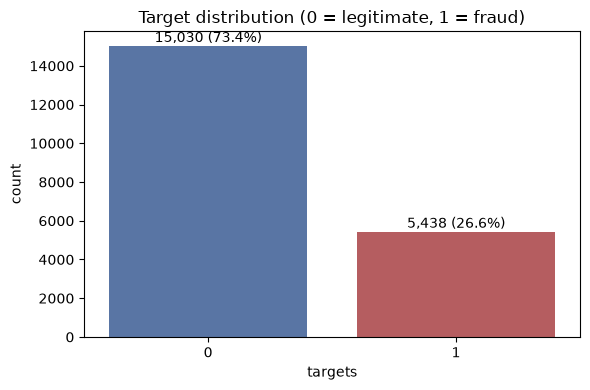

In [14]:
counts = df_raw[TARGET_COL].value_counts().sort_index()
props = df_raw[TARGET_COL].value_counts(normalize=True).sort_index()
print("Class counts:", counts.to_dict())
print("Class proportions:", props.round(4).to_dict())

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=TARGET_COL, data=df_raw, ax=ax, palette=["#4c72b0", "#c44e52"])
ax.set_title("Target distribution (0 = legitimate, 1 = fraud)")
ax.set_xlabel("targets")
for i, (cls, cnt) in enumerate(counts.items()):
    ax.text(i, cnt + 200, f"{cnt:,} ({props[cls]*100:.1f}%)", ha="center")
plt.tight_layout(); plt.show()

### 3.2 Which raw features relate to the label?
Fraud flag `col_83` stands out (|corr| ≈ 0.52), followed by other binary flags. No feature equals the label,
so this is genuine signal rather than leakage.

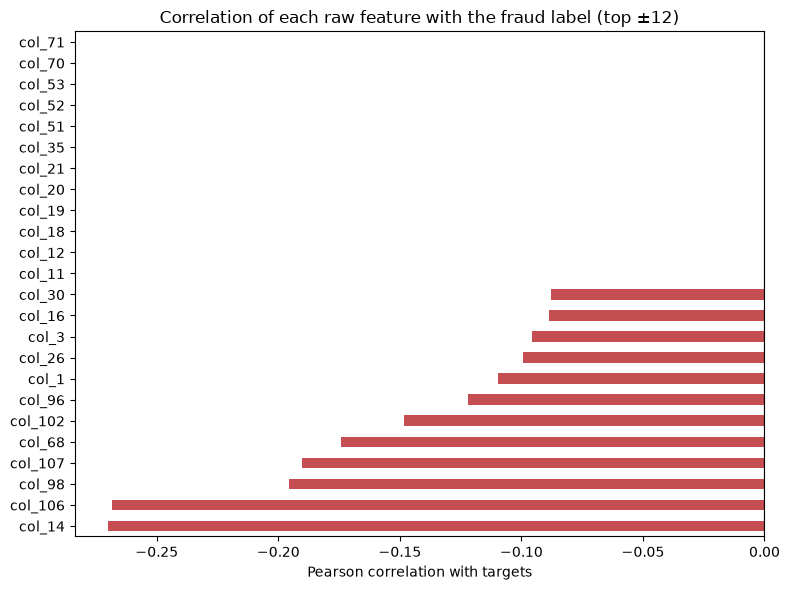

In [15]:
corr_series = df_raw[feat_cols].corrwith(df_raw[TARGET_COL]).sort_values()
top = pd.concat([corr_series.head(12), corr_series.tail(12)])

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#c44e52" if v < 0 else "#4c72b0" for v in top]
top.plot.barh(ax=ax, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Correlation of each raw feature with the fraud label (top ±12)")
ax.set_xlabel("Pearson correlation with targets")
plt.tight_layout(); plt.show()

### 3.3 Numerical feature distributions
The continuous-like features (many unique values) are all heavily **right-skewed** — e.g. `col_67` spans
0 to ~24.9 million with ~51% zeros, and `col_1` reaches ~38k with a mean of ~295. This motivates
log-transformation before scaling later. Histograms below use a `log1p` axis to make the shapes visible.

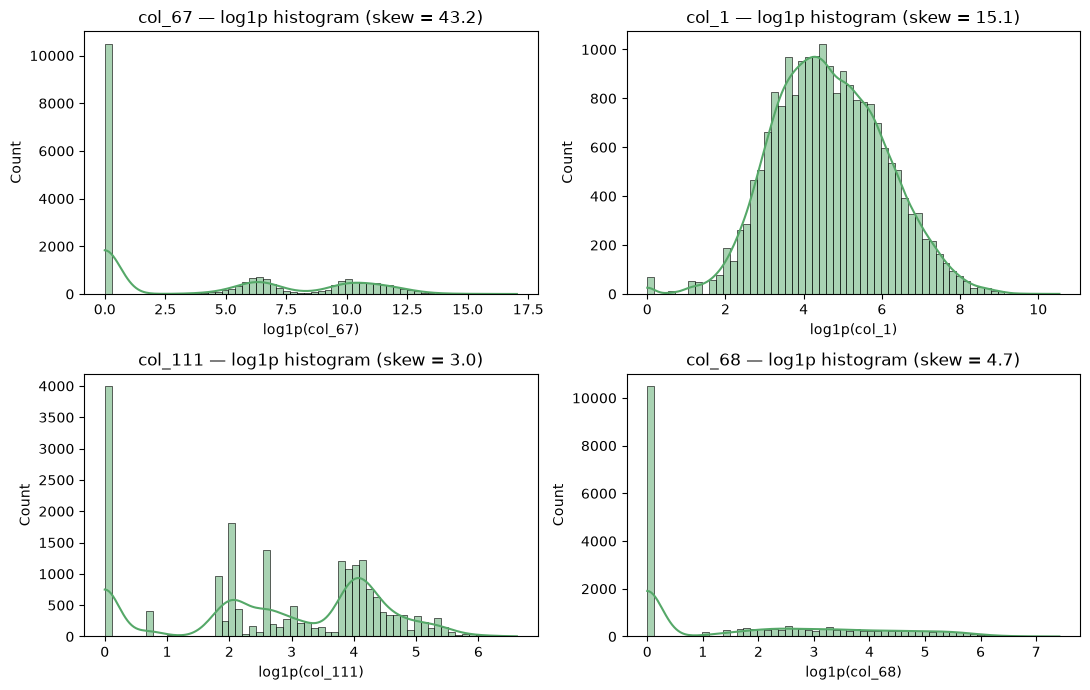

Raw range of representative columns:
         min   50%       75%          max
col_67   0.0   0.0  11627.44  24926557.33
col_1    0.0  97.0    283.00     37808.00
col_111  0.0  19.0     61.25       747.00
col_68   0.0   0.0     27.00      1665.00


In [16]:
continuous_like = [c for c in feat_cols if nuniq[c] > 100]
# Representative picks: the single float column + high-cardinality count-like columns
show_cols = ["col_67", "col_1", "col_111", "col_68"]
show_cols = [c for c in show_cols if c in df_raw.columns]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, c in zip(axes.ravel(), show_cols):
    sns.histplot(np.log1p(df_raw[c]), bins=60, kde=True, ax=ax, color="#55a868")
    ax.set_title(f"{c} — log1p histogram (skew = {stats.skew(df_raw[c]):.1f})")
    ax.set_xlabel(f"log1p({c})")
plt.tight_layout(); plt.show()

print("Raw range of representative columns:")
print(df_raw[show_cols].describe().T[["min", "50%", "75%", "max"]].round(2).to_string())

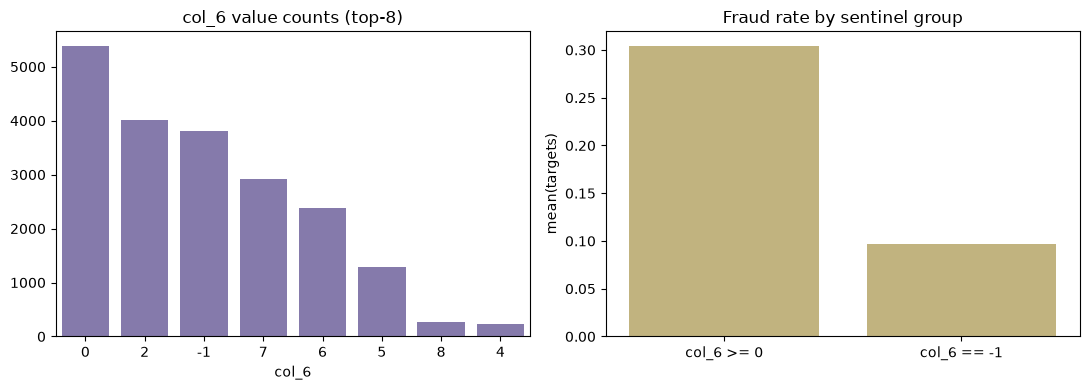

In [17]:
# Distribution of the -1 sentinel column col_6 (value counts)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
top_vals = df_raw["col_6"].value_counts().head(8)
sns.barplot(x=top_vals.index.astype(str), y=top_vals.values, ax=axes[0], color="#8172b3")
axes[0].set_title("col_6 value counts (top-8)")
axes[0].set_xlabel("col_6")
# Compare fraud rate for the -1 group vs the rest (informative sentinel)
grp = df_raw.groupby(df_raw["col_6"] == -1)[TARGET_COL].mean()
sns.barplot(x=["col_6 >= 0", "col_6 == -1"], y=grp.values, ax=axes[1], color="#ccb974")
axes[1].set_title("Fraud rate by sentinel group")
axes[1].set_ylabel("mean(targets)")
plt.tight_layout(); plt.show()

### 3.4 Outlier analysis
Count features contain extreme values far beyond the IQR fences (e.g. `col_67` max ≈ 24.9M). We do **not**
delete outlier rows: for fraud detection extreme values are often exactly where fraud hides, and the dataset
has no documented measurement errors. Outliers are instead tamed with a log transform (Section 5) before
standardisation.

In [18]:
def iqr_outlier_fraction(s: pd.Series) -> float:
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return 0.0
    return float(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).mean())

outlier_stats = []
for c in feat_cols:
    s = df_raw[c]
    if s.nunique() <= 10:      # skip binary / tiny-count columns
        continue
    outlier_stats.append((c, iqr_outlier_fraction(s), float(s.max()), int(s.nunique())))
out_df = pd.DataFrame(outlier_stats, columns=["col", "frac_outliers_IQR", "max", "n_unique"])
out_df = out_df.sort_values("frac_outliers_IQR", ascending=False)
print("Features with the most IQR-outliers (top 12):")
print(out_df.head(12).round(3).to_string(index=False))

# Share of rows with an extreme value on any continuous-like (n_unique > 100) feature
cont_cols = [c for c in feat_cols if df_raw[c].nunique() > 100]
row_flagged = pd.Series(False, index=df_raw.index)
for c in cont_cols:
    q1, q3 = df_raw[c].quantile(0.25), df_raw[c].quantile(0.75)
    row_flagged |= (df_raw[c] > q3 + 1.5 * (q3 - q1)) | (df_raw[c] < q1 - 1.5 * (q3 - q1))
print(f"Rows with at least one extreme continuous-like value: "
      f"{int(row_flagged.sum())} / {len(df_raw)} ({row_flagged.mean():.1%})")

Features with the most IQR-outliers (top 12):
   col  frac_outliers_IQR          max  n_unique
col_47              0.184    95635.000       441
col_49              0.179    41900.000       503
col_50              0.176   291269.000       357
col_38              0.176    73318.000      1575
col_67              0.169 24926557.333      9743
col_30              0.169      973.000       211
col_36              0.167    94642.000       346
col_54              0.164   121855.000      1686
col_68              0.154     1665.000       543
col_25              0.151      693.000       152
col_22              0.147     3349.000       167
col_24              0.136      909.000       132
Rows with at least one extreme continuous-like value: 11398 / 20468 (55.7%)


### 3.5 Correlations & redundancy among features
Two findings worth acting on:
- exact duplicates (`col_0`/`col_7`) — handled by removing the copy in cleaning;
- near-duplicate groups (corr ≈ 0.99+ between `col_40/47/50/55/57/63/36/49/65`…) — kept, but the analyst
  should know they encode very similar information.

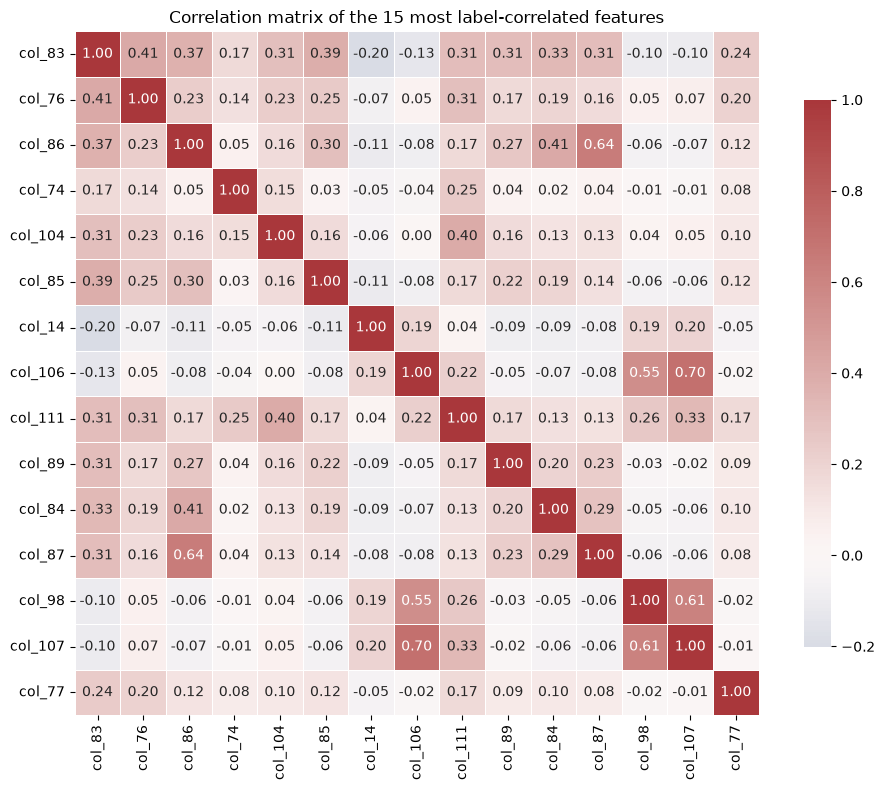

In [19]:
# Heatmap of the most label-correlated features -> shows internal redundancy too
top_n = 15
strongest = corr_series.abs().sort_values(ascending=False).head(top_n).index.tolist()
sub = df_raw[strongest].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sub, annot=True, fmt=".2f", cmap="vlag", center=0, square=True,
            linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title(f"Correlation matrix of the {top_n} most label-correlated features")
plt.tight_layout(); plt.show()

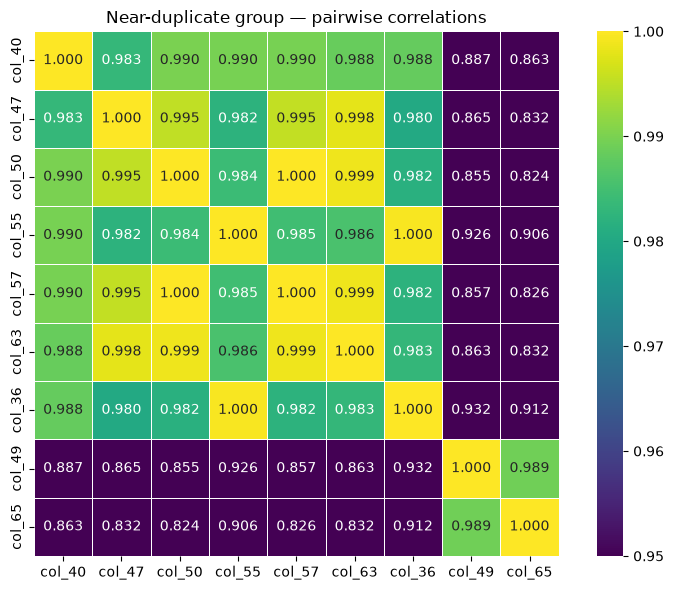

In [20]:
# Near-duplicate group example (correlations > 0.99)
near_dup_group = ["col_40", "col_47", "col_50", "col_55", "col_57", "col_63", "col_36", "col_49", "col_65"]
near_dup_group = [c for c in near_dup_group if c in df_raw.columns]
g = df_raw[near_dup_group].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(g, annot=True, fmt=".3f", cmap="viridis", vmin=0.95, vmax=1.0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Near-duplicate group — pairwise correlations")
plt.tight_layout(); plt.show()

**EDA conclusions**
- Imbalanced binary label (26.6% fraud) → stratified split for classification.
- Features are anonymised counts/flags, all right-skewed, some near-duplicates; `col_6` has an informative
  `-1` sentinel; `col_67` is the only continuous float column (candidate regression target).
- No missing values; **175 exact duplicate rows** (once the row-id artefact is excluded) and the
  duplicate feature column `col_7` were found and are removed in common cleaning; no exact label leak.

---
## SECTION 4 — Common Dataset Cleaning

The cleaning step operates on `df_raw` and produces `df_clean` (20,293 rows × 97 columns: 96 features + `targets`).

Cleaning operations executed:
1. **Drop row-id column**: `Unnamed: 0` carries no behavioral information.
2. **Drop constant columns**: 15 columns with 100% zero variance carry no predictive value.
3. **Drop exact-duplicate feature columns**: `col_7` is an exact clone of `col_0`.
4. **Drop exact duplicate rows**: 175 duplicate rows are dropped to eliminate train-test row overlap leakage downstream.

The cleaned dataframe `df_clean` is stored separately; **`df_raw` remains completely untouched**.

In [21]:
before_rows, before_cols = df_raw.shape

# 1) drop row-id
df_no_id = df_raw.drop(columns=[df_raw.columns[0]])

# 2) drop constant columns (derived from the data, not hard-coded)
constant_cols = df_no_id.columns[df_no_id.nunique() == 1].tolist()
df_no_const = df_no_id.drop(columns=constant_cols)

# 3) drop exact-duplicate feature columns among the remaining ones
feats_no_const = [c for c in df_no_const.columns if c != TARGET_COL]
dup_det = df_no_const[feats_no_const].T.duplicated(keep="first")
dup_cols = [c for c, is_dup in zip(feats_no_const, dup_det) if is_dup]
df_no_dup_cols = df_no_const.drop(columns=dup_cols)

# 4) drop exact duplicate rows (175 duplicate rows present in feature+target matrix)
dup_rows_count = int(df_no_dup_cols.duplicated().sum())
df_clean = df_no_dup_cols.drop_duplicates().reset_index(drop=True)

print(f"Shape before cleaning        : {before_rows} x {before_cols}")
print(f"  - dropped row-id column    : {df_raw.columns[0]}")
print(f"  - dropped constant columns ({len(constant_cols)}): {constant_cols}")
print(f"  - dropped exact dup cols   ({len(dup_cols)}): {dup_cols}")
print(f"  - dropped exact dup rows   ({dup_rows_count})")
print(f"Shape after cleaning         : {df_clean.shape}")
print(f"Feature columns kept         : {df_clean.shape[1] - 1} (+ {TARGET_COL})")


Shape before cleaning        : 20468 x 114
  - dropped row-id column    : Unnamed: 0
  - dropped constant columns (15): ['col_8', 'col_9', 'col_10', 'col_11', 'col_12', 'col_18', 'col_19', 'col_20', 'col_21', 'col_35', 'col_51', 'col_52', 'col_53', 'col_70', 'col_71']
  - dropped exact dup cols   (1): ['col_7']
  - dropped exact dup rows   (175)
Shape after cleaning         : (20293, 97)
Feature columns kept         : 96 (+ targets)


In [22]:
# What changed — verify cleaning results explicitly
print("Missing values after cleaning :", int(df_clean.isna().sum().sum()))
print("Duplicate rows after cleaning :", int(df_clean.duplicated().sum()))
print("Remaining constant columns    :", df_clean.columns[df_clean.nunique() == 1].tolist() or "none")
print()
print("Cleaned feature columns:")
print(df_clean.columns.tolist())

Missing values after cleaning : 0
Duplicate rows after cleaning : 0
Remaining constant columns    : none

Cleaned feature columns:
['col_0', 'col_1', 'col_2', 'col_3', 'col_4', 'col_5', 'col_6', 'col_13', 'col_14', 'col_15', 'col_16', 'col_17', 'col_22', 'col_23', 'col_24', 'col_25', 'col_26', 'col_27', 'col_28', 'col_29', 'col_30', 'col_31', 'col_32', 'col_33', 'col_34', 'col_36', 'col_37', 'col_38', 'col_39', 'col_40', 'col_41', 'col_42', 'col_43', 'col_44', 'col_45', 'col_46', 'col_47', 'col_48', 'col_49', 'col_50', 'col_54', 'col_55', 'col_56', 'col_57', 'col_58', 'col_59', 'col_60', 'col_61', 'col_62', 'col_63', 'col_64', 'col_65', 'col_66', 'col_67', 'col_68', 'col_69', 'col_72', 'col_73', 'col_74', 'col_75', 'col_76', 'col_77', 'col_78', 'col_79', 'col_80', 'col_81', 'col_82', 'col_83', 'col_84', 'col_85', 'col_86', 'col_87', 'col_88', 'col_89', 'col_90', 'col_91', 'col_92', 'col_93', 'col_94', 'col_95', 'col_96', 'col_97', 'col_98', 'col_99', 'col_100', 'col_101', 'col_102', 'c

In [23]:
print("Head of cleaned data:")
df_clean.head()

Head of cleaned data:


,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_13,col_14,col_15,...,col_103,col_104,col_105,col_106,col_107,col_108,col_109,col_110,col_111,targets
0,9,1354,0,18,0,1,7,0,1,0,...,0,0,0,1,1,0,0,0,49,1
1,0,239,0,1,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,55,1
2,0,260,0,4,0,3,6,0,1,1,...,0,0,0,1,1,0,0,0,56,1
3,17,682,0,1,0,0,8,0,0,0,...,0,1,0,1,1,0,0,0,65,1
4,1,540,0,2,0,1,7,0,1,0,...,0,0,0,1,1,0,0,0,175,1


In [24]:
print("dtypes of cleaned data:")
print(df_clean.dtypes.value_counts().to_string())
print()
df_clean.info(verbose=False)

dtypes of cleaned data:
int64      96
float64     1

<class 'pandas.DataFrame'>
RangeIndex: 20293 entries, 0 to 20292
Columns: 97 entries, col_0 to targets
dtypes: float64(1), int64(96)
memory usage: 15.0 MB


In [25]:
# Summary statistics after cleaning (key numeric features)
with pd.option_context("display.float_format", lambda v: f"{v:,.2f}"):
    display(df_clean.describe().T.head(12))

,count,mean,std,min,25%,50%,75%,max
col_0,"20,293.00",3.25,20.65,0.00,0.00,0.00,2.00,"2,301.00"
col_1,"20,293.00",297.24,720.14,0.00,38.00,99.00,285.00,"37,808.00"
col_2,"20,293.00",0.42,7.40,0.00,0.00,0.00,0.00,904.00
col_3,"20,293.00",2.34,10.11,0.00,0.00,1.00,2.00,772.00
col_4,"20,293.00",0.08,0.84,0.00,0.00,0.00,0.00,54.00
col_5,"20,293.00",0.94,4.24,0.00,0.00,0.00,1.00,230.00
col_6,"20,293.00",2.39,3.02,-1.00,0.00,2.00,6.00,11.00
col_13,"20,293.00",0.04,0.19,0.00,0.00,0.00,0.00,1.00
col_14,"20,293.00",0.36,0.48,0.00,0.00,0.00,1.00,1.00
col_15,"20,293.00",0.33,0.47,0.00,0.00,0.00,1.00,1.00


---
## SECTION 5 — Task-Specific Feature Engineering & Preprocessing Strategy

To guarantee **zero data leakage**:
- Feature transformation selection (e.g. evaluating skewness to identify log-eligible features) and numerical scaling (`StandardScaler`) for **supervised tasks** (Classification & Regression) are fitted on **training data splits (`X_train`) only** after train/test splitting.
- `log1p` is applied **only to non-binary, non-negative, right-skewed** features (skew > 1.0). Binary
  flag features (at most 2 unique values, e.g. 0/1) are **never** log-transformed.
- The parameters learned from `X_train` are then applied consistently to both `X_train` and `X_test`.
- For **unsupervised Clustering**, transformation and scaling are performed on the full clean feature matrix $X_{clu}$ (since clustering operates on the complete unlabeled dataset without train/test splits).


In [26]:
# Helper function to apply log1p transformation to skewed features learned from fit data
from scipy.stats import skew as skewness

def apply_log1p_transform(df_train, df_test=None, skew_threshold=1.0):
    """
    Fits log-eligibility on df_train ONLY, then transforms df_train and (if provided) df_test.
    A feature is log-transformed only if it is:
      - non-binary (more than 2 unique values; binary 0/1-style flags are never log-transformed), and
      - non-negative (min >= 0), and
      - right-skewed (skewness > skew_threshold).
    """
    train_tr = df_train.copy()
    test_tr = df_test.copy() if df_test is not None else None
    
    log_eligible = [
        c for c in df_train.columns
        if df_train[c].nunique() > 2                      # exclude binary flag features
        and df_train[c].min() >= 0                        # non-negative (log1p-safe)
        and skewness(df_train[c]) > skew_threshold        # right-skewed
    ]
    
    train_tr[log_eligible] = np.log1p(df_train[log_eligible])
    if test_tr is not None:
        test_tr[log_eligible] = np.log1p(df_test[log_eligible])
        return train_tr, test_tr, log_eligible
    return train_tr, log_eligible

print("Defined leakage-free log1p transformer function.")


Defined leakage-free log1p transformer function.


In [27]:
# Demonstrate skewness reduction on the cleaned dataset for visualization
feat_cols_clean = [c for c in df_clean.columns if c != TARGET_COL]
skew_demo = {c: skewness(df_clean[c]) for c in feat_cols_clean}
demo_eligible = [c for c in feat_cols_clean
                 if df_clean[c].nunique() > 2 and df_clean[c].min() >= 0 and skew_demo[c] > 1.0]
print(f"Identified {len(demo_eligible)} non-binary skewed non-negative features (skew > 1.0) in df_clean for demonstration.")


Identified 53 non-binary skewed non-negative features (skew > 1.0) in df_clean for demonstration.


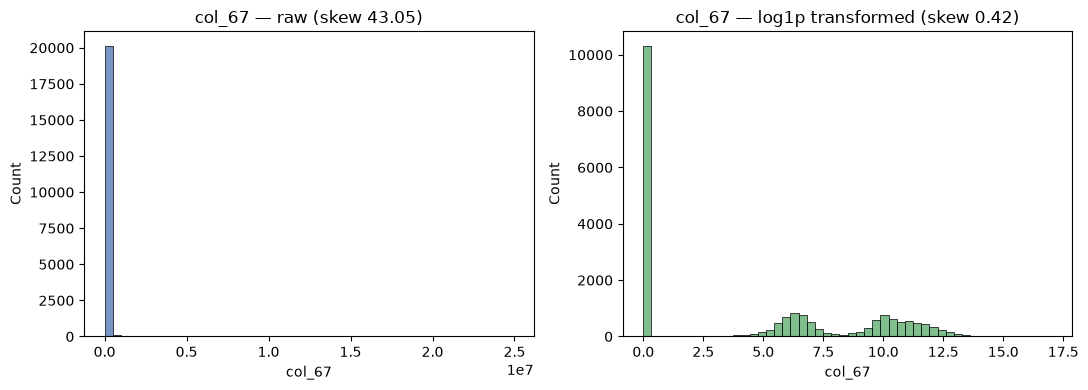

In [28]:
# Visual proof of skew reduction on top skewed features
sample_feat = 'col_67'
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df_clean[sample_feat], bins=50, ax=axes[0], color="#4c72b0")
axes[0].set_title(f"{sample_feat} — raw (skew {skew_demo[sample_feat]:.2f})")

sns.histplot(np.log1p(df_clean[sample_feat]), bins=50, ax=axes[1], color="#55a868")
axes[1].set_title(f"{sample_feat} — log1p transformed (skew {skewness(np.log1p(df_clean[sample_feat])):.2f})")
plt.tight_layout()
plt.show()


In [29]:
print(f"Clean dataset shape ready for task splitting: {df_clean.shape}")


Clean dataset shape ready for task splitting: (20293, 97)


---
## SECTION 6 — Task-Specific Data Preparation

Three independent branches are built from the **same cleaned + engineered table**. Each task defines its own
feature matrix and target, and (for the two supervised tasks) its own split + fitted scaler:

| Branch       | Features                      | Target         | Split |
|--------------|-------------------------------|----------------|-------|
| Classification | all engineered features      | `targets` (0/1) | stratified 80/20 |
| Regression   | all engineered features **except `col_67`** | `col_67` (continuous) | plain 80/20 |
| Clustering   | all engineered features      | none           | none (full matrix) |

**No test-set leakage:** the `StandardScaler` is always `.fit()` on the training split only, then used to
`.transform()` both splits. Feature selection is purely structural (done above); the log1p transform is
parameter-free. Test rows contribute to no fitted statistic.

### 6A. Classification — binary fraud flag

Target: `targets` (0 = legitimate, 1 = fraud). Because the label is imbalanced (≈27% fraud), the split is
**stratified** so both classes keep the same proportion in train and test.

In [30]:
X_cls = df_clean.drop(columns=[TARGET_COL])
y_cls = df_clean[TARGET_COL]          # raw binary fraud label (0/1)

print("X_cls shape:", X_cls.shape)
print("y_cls distribution:\n", y_cls.value_counts().to_string())

X_cls_tr_raw, X_cls_te_raw, y_cls_train, y_cls_test = train_test_split(
    X_cls, y_cls, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_cls
)
print(f"\nSplit sizes: train={X_cls_tr_raw.shape[0]}, test={X_cls_te_raw.shape[0]}")
print("Class share in train: %.3f | in test: %.3f | overall: %.3f"
      % (y_cls_train.mean(), y_cls_test.mean(), y_cls.mean()))


X_cls shape: (20293, 96)
y_cls distribution:
 targets
0    14916
1     5377

Split sizes: train=16234, test=4059
Class share in train: 0.265 | in test: 0.265 | overall: 0.265


In [31]:
# 1) Fit log-transformation selection on TRAIN only -> transform TRAIN and TEST
X_cls_tr_eng, X_cls_te_eng, log_cols_cls = apply_log1p_transform(X_cls_tr_raw, X_cls_te_raw)
print(f"Log1p transformed {len(log_cols_cls)} non-binary skewed features fitted on X_cls_train only.")

# 2) Fit StandardScaler on TRAIN only -> transform TRAIN and TEST
scaler_cls = StandardScaler().fit(X_cls_tr_eng)
X_cls_train_sc = pd.DataFrame(scaler_cls.transform(X_cls_tr_eng),
                              columns=X_cls_tr_eng.columns, index=X_cls_tr_eng.index)
X_cls_test_sc = pd.DataFrame(scaler_cls.transform(X_cls_te_eng),
                             columns=X_cls_te_eng.columns, index=X_cls_te_eng.index)

print("Scaler fitted on training split only. n_features:", scaler_cls.n_features_in_)
print("Mean of scaled TRAIN features ~ 0:", np.round(X_cls_train_sc.mean(axis=0).abs().max(), 10))
print("Mean of scaled TEST features (not 0 -> test not used for fitting):",
      np.round(X_cls_test_sc.mean(axis=0).abs().max(), 4))
X_cls_train_sc.head()


Log1p transformed 53 non-binary skewed features fitted on X_cls_train only.
Scaler fitted on training split only. n_features: 96
Mean of scaled TRAIN features ~ 0: 0.0
Mean of scaled TEST features (not 0 -> test not used for fitting): 0.0479


,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_13,col_14,col_15,...,col_102,col_103,col_104,col_105,col_106,col_107,col_108,col_109,col_110,col_111
2692,-0.638331,-0.928933,-0.310102,-1.035475,-0.192804,0.526413,-0.132304,-0.203409,-0.760738,1.426719,...,-0.713055,-0.069958,-0.750277,-0.045132,-0.672449,-0.488635,-0.007849,-0.229758,-0.108988,-0.006122
14598,-0.638331,-0.797806,-0.310102,-0.082448,-0.192804,-0.697066,-1.123458,-0.203409,-0.760738,-0.700909,...,-0.713055,-0.069958,-0.750277,-0.045132,-0.672449,-0.488635,-0.007849,-0.229758,-0.108988,-1.639055
17664,-0.638331,0.103194,2.383254,-1.035475,-0.192804,-0.697066,1.189234,-0.203409,1.314513,1.426719,...,-0.713055,-0.069958,-0.750277,-0.045132,1.487102,-0.488635,-0.007849,-0.229758,-0.108988,-0.583787
3253,-0.638331,-1.427451,-0.310102,-1.035475,-0.192804,0.526413,-0.132304,-0.203409,-0.760738,1.426719,...,-0.713055,-0.069958,1.332842,-0.045132,-0.672449,-0.488635,-0.007849,-0.229758,-0.108988,0.782070
2546,-0.638331,-0.704270,-0.310102,-1.035475,-0.192804,0.526413,-0.132304,-0.203409,-0.760738,1.426719,...,1.281676,-0.069958,1.332842,-0.045132,-0.672449,-0.488635,-0.007849,-0.229758,-0.108988,0.926856


In [32]:
# Save classification files exactly under data/processed/classification/
X_cls_train_sc.to_csv(CLASS_DIR / "X_train.csv", index=False)
X_cls_test_sc.to_csv(CLASS_DIR / "X_test.csv", index=False)
y_cls_train.to_csv(CLASS_DIR / "y_train.csv", index=False)
y_cls_test.to_csv(CLASS_DIR / "y_test.csv", index=False)
print("Saved to", CLASS_DIR.relative_to(PROJECT_ROOT).as_posix())
for f in sorted(CLASS_DIR.glob("*.csv")):
    print(" -", f.name)

Saved to data/processed/classification
 - X_test.csv
 - X_train.csv
 - y_test.csv
 - y_train.csv


### 6B. Regression — continuous target `col_67`

`col_67` is the **only continuous float column** in the raw dataset (range 0 – ~24.9M, ~9.7k unique values),
so it is the natural regression target for this case study. It is therefore **excluded from the feature
matrix** of this branch. The target is saved **raw** (untransformed) — transforming the target (e.g. for a
log-space model) is a modelling decision, not a preprocessing one. No stratification is needed for
regression.

In [33]:
# Drop classification label and drop regression duplicates (4 rows that differ only in classification label)
df_reg = df_clean.drop(columns=[TARGET_COL]).drop_duplicates().reset_index(drop=True)
X_reg = df_reg.drop(columns=[REG_TARGET_COL])
y_reg = df_reg[REG_TARGET_COL]     # raw continuous target

print("X_reg shape:", X_reg.shape)
print("y_reg describe:\n", y_reg.describe().round(3).to_string())

X_reg_tr_raw, X_reg_te_raw, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f"\nSplit sizes: train={X_reg_tr_raw.shape[0]}, test={X_reg_te_raw.shape[0]}")


X_reg shape: (20289, 95)
y_reg describe:
 count    2.028900e+04
mean     3.713295e+04
std      3.766429e+05
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.214571e+04
max      2.492656e+07

Split sizes: train=16231, test=4058


In [34]:
# 1) Fit log-transformation selection on TRAIN only -> transform TRAIN and TEST
X_reg_tr_eng, X_reg_te_eng, log_cols_reg = apply_log1p_transform(X_reg_tr_raw, X_reg_te_raw)
print(f"Log1p transformed {len(log_cols_reg)} non-binary skewed features fitted on X_reg_train only.")

# 2) Fit StandardScaler on TRAIN only -> transform TRAIN and TEST
scaler_reg = StandardScaler().fit(X_reg_tr_eng)   # fit on TRAIN only
X_reg_train_sc = pd.DataFrame(scaler_reg.transform(X_reg_tr_eng),
                              columns=X_reg_tr_eng.columns, index=X_reg_tr_eng.index)
X_reg_test_sc = pd.DataFrame(scaler_reg.transform(X_reg_te_eng),
                             columns=X_reg_te_eng.columns, index=X_reg_te_eng.index)

print("Scaler fitted on training split only. n_features:", scaler_reg.n_features_in_)
print("Mean of scaled TRAIN features ~ 0:", np.round(X_reg_train_sc.mean(axis=0).abs().max(), 10))
print("Mean of scaled TEST features (not 0 -> no leakage):",
      np.round(X_reg_test_sc.mean(axis=0).abs().max(), 4))
X_reg_train_sc.head()


Log1p transformed 52 non-binary skewed features fitted on X_reg_train only.


Scaler fitted on training split only. n_features: 95


Mean of scaled TRAIN features ~ 0: 0.0
Mean of scaled TEST features (not 0 -> no leakage): 0.0419


,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_13,col_14,col_15,...,col_102,col_103,col_104,col_105,col_106,col_107,col_108,col_109,col_110,col_111
181,0.784878,0.116314,-0.306665,-0.078318,-0.197176,1.247761,-1.131329,4.923679,1.321148,-0.702179,...,-0.717506,-0.065724,-0.754603,-0.045817,1.483067,-0.489658,-0.007849,4.360455,-0.109821,0.789150
1063,-0.636596,0.045549,-0.306665,-0.078318,-0.197176,0.528566,-0.800567,-0.203100,-0.756917,-0.702179,...,-0.717506,-0.065724,1.325200,-0.045817,-0.674278,-0.489658,-0.007849,-0.229334,-0.109821,0.946303
9891,-0.636596,-0.128944,-0.306665,0.880707,-0.197176,-0.700907,-0.800567,-0.203100,-0.756917,-0.702179,...,-0.717506,-0.065724,1.325200,-0.045817,-0.674278,-0.489658,-0.007849,-0.229334,-0.109821,0.613666
9750,0.074141,-0.490914,-0.306665,0.482676,-0.197176,-0.700907,-0.800567,-0.203100,1.321148,-0.702179,...,-0.717506,-0.065724,-0.754603,-0.045817,-0.674278,-0.489658,-0.007849,-0.229334,-0.109821,-1.637183
11632,-0.636596,0.761403,-0.306665,-1.037343,-0.197176,0.528566,1.514769,-0.203100,1.321148,-0.702179,...,1.281175,-0.065724,1.325200,-0.045817,1.483067,2.042243,-0.007849,-0.229334,-0.109821,1.584872


In [35]:
X_reg_train_sc.to_csv(REG_DIR / "X_train.csv", index=False)
X_reg_test_sc.to_csv(REG_DIR / "X_test.csv", index=False)
y_reg_train.to_csv(REG_DIR / "y_train.csv", index=False)
y_reg_test.to_csv(REG_DIR / "y_test.csv", index=False)
print("Saved to", REG_DIR.relative_to(PROJECT_ROOT).as_posix())
for f in sorted(REG_DIR.glob("*.csv")):
    print(" -", f.name)

Saved to data/processed/regression
 - X_test.csv
 - X_train.csv
 - y_test.csv
 - y_train.csv


### 6C. Clustering — unsupervised feature matrix

Clustering has **no target** and therefore **no train/test split**: a single feature matrix is used.
Scaling is fitted on the whole matrix — legitimate here because there is no held-out evaluation set whose
information could leak (leakage is a supervised-evaluation concern). The engineered features (log1p-skew
corrected) are standardised so that no feature dominates the distance computations used by clustering
algorithms.

In [36]:
# Features only (drop classification target and deduplicate for unsupervised clustering)
X_clu_raw = df_clean.drop(columns=[TARGET_COL]).drop_duplicates().reset_index(drop=True)
print("X_clu_raw shape:", X_clu_raw.shape)

# 1) Log1p transform skewed features on full unsupervised matrix
X_clu_eng, log_cols_clu = apply_log1p_transform(X_clu_raw)
print(f"Log1p transformed {len(log_cols_clu)} non-binary skewed features for clustering.")

# 2) Fit StandardScaler on full matrix (unsupervised — no train/test concept)
scaler_clu = StandardScaler().fit(X_clu_eng)
X_clu_sc = pd.DataFrame(scaler_clu.transform(X_clu_eng),
                        columns=X_clu_eng.columns, index=X_clu_eng.index)
print("Scaler fitted on full unsupervised matrix.")
X_clu_sc.head()


X_clu_raw shape: (20289, 96)
Log1p transformed 53 non-binary skewed features for clustering.


Scaler fitted on full unsupervised matrix.


,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_13,col_14,col_15,...,col_102,col_103,col_104,col_105,col_106,col_107,col_108,col_109,col_110,col_111
0,1.732889,1.809863,-0.310219,2.998898,-0.194896,0.531616,1.524232,-0.201416,1.322005,-0.702563,...,3.926055,-0.068406,-0.751281,-0.049704,1.488242,2.048653,-0.007021,-0.228647,-0.109077,0.663270
1,-0.636545,0.568179,-0.310219,-0.085584,-0.194896,0.531616,-0.792754,-0.201416,-0.756427,-0.702563,...,-0.713852,-0.068406,1.331060,-0.049704,-0.671934,-0.488126,-0.007021,-0.228647,-0.109077,0.729929
2,-0.636545,0.628352,-0.310219,1.169821,-0.194896,1.759655,1.193234,-0.201416,1.322005,1.423359,...,1.284447,-0.068406,-0.751281,-0.049704,1.488242,2.048653,-0.007021,-0.228647,-0.109077,0.740340
3,2.337741,1.318430,-0.310219,-0.085584,-0.194896,-0.696423,1.855230,-0.201416,-0.756427,-0.702563,...,1.284447,-0.068406,1.331060,-0.049704,1.488242,2.048653,-0.007021,-0.228647,-0.109077,0.826570
4,0.076726,1.151232,-0.310219,0.469942,-0.194896,0.531616,1.524232,-0.201416,1.322005,-0.702563,...,1.284447,-0.068406,-0.751281,-0.049704,1.488242,2.048653,-0.007021,-0.228647,-0.109077,1.403482


In [37]:
X_clu_sc.to_csv(CLU_DIR / "X.csv", index=False)
print("Saved to", CLU_DIR.relative_to(PROJECT_ROOT).as_posix())
for f in sorted(CLU_DIR.glob("*.csv")):
    print(" -", f.name)

Saved to data/processed/clustering
 - X.csv


---
## SECTION 7 — Final Verification

Checks performed:
1. Every expected file exists **exactly** under `data/processed/`.
2. Shapes are consistent: train + test row counts add up to the total; feature columns identical across splits.
3. No missing values in any output; raw label / target values are preserved.
4. The raw CSV is byte-identical to when it was loaded (SHA-256 comparison).

In [38]:
expected = {
    CLASS_DIR / "X_train.csv": None, CLASS_DIR / "X_test.csv": None,
    CLASS_DIR / "y_train.csv": None, CLASS_DIR / "y_test.csv": None,
    REG_DIR / "X_train.csv": None, REG_DIR / "X_test.csv": None,
    REG_DIR / "y_train.csv": None, REG_DIR / "y_test.csv": None,
    CLU_DIR / "X.csv": None,
}
missing = [str(p) for p in expected if not p.is_file()]
print("Missing files:", missing or "none")

summary = []
for path in expected:
    df_check = pd.read_csv(path)
    expected[path] = df_check
    summary.append({
        "file": str(path.relative_to(PROJECT_ROOT)),
        "rows": df_check.shape[0],
        "cols": df_check.shape[1],
        "any_NaN": int(df_check.isna().sum().sum()),
    })
print("\nOutput summary:")
print(pd.DataFrame(summary).to_string(index=False))

Missing files: none



Output summary:
                                     file  rows  cols  any_NaN
data\processed\classification\X_train.csv 16234    96        0
 data\processed\classification\X_test.csv  4059    96        0
data\processed\classification\y_train.csv 16234     1        0
 data\processed\classification\y_test.csv  4059     1        0
    data\processed\regression\X_train.csv 16231    95        0
     data\processed\regression\X_test.csv  4058    95        0
    data\processed\regression\y_train.csv 16231     1        0
     data\processed\regression\y_test.csv  4058     1        0
          data\processed\clustering\X.csv 20289    96        0


In [39]:
# Consistency & Data Leakage Assertions
Xc_tr, Xc_te, yc_tr, yc_te = (expected[CLASS_DIR / "X_train.csv"], expected[CLASS_DIR / "X_test.csv"],
                              expected[CLASS_DIR / "y_train.csv"], expected[CLASS_DIR / "y_test.csv"])
Xr_tr, Xr_te, yr_tr, yr_te = (expected[REG_DIR / "X_train.csv"], expected[REG_DIR / "X_test.csv"],
                              expected[REG_DIR / "y_train.csv"], expected[REG_DIR / "y_test.csv"])
Xclu = expected[CLU_DIR / "X.csv"]

# Shape consistency
assert Xc_tr.shape[1] == Xc_te.shape[1] == 96, "classification feature width mismatch"
assert Xr_tr.shape[1] == Xr_te.shape[1] == 95, "regression feature width mismatch"
assert Xclu.shape[1] == 96, "clustering feature width mismatch"
assert Xc_tr.shape[0] + Xc_te.shape[0] == 20293, "classification rows mismatch (expected 20,293 clean unique rows)"
assert Xr_tr.shape[0] + Xr_te.shape[0] == 20289, "regression rows mismatch (expected 20,289 clean unique rows)"
assert Xclu.shape[0] == 20289, "clustering row count mismatch"
assert list(Xc_tr.columns) == list(Xc_te.columns), "train/test classification columns differ"
assert list(Xr_tr.columns) == list(Xr_te.columns), "train/test regression columns differ"
assert set(yc_tr.iloc[:, 0]) <= {0, 1}, "classification y not binary"
assert yr_tr.columns[0] == REG_TARGET_COL, "regression target column header mismatch"
assert yc_tr.columns[0] == TARGET_COL, "classification target column header mismatch"

# Zero NaNs check
for df_check in expected.values():
    assert df_check.isna().sum().sum() == 0, f"NaNs found in {df_check}"

# Zero train-test row leakage check (MUST have 0 matching rows between train and test)
cls_overlap = len(pd.merge(Xc_te, Xc_tr, how='inner'))
reg_overlap = len(pd.merge(Xr_te, Xr_tr, how='inner'))
assert cls_overlap == 0, f"Classification train-test row leakage detected! {cls_overlap} matching rows."
assert reg_overlap == 0, f"Regression train-test row leakage detected! {reg_overlap} matching rows."

# Refinement check: binary (flag-like) features must never be log-transformed
for _name, _cols in [("classification", log_cols_cls),
                     ("regression", log_cols_reg),
                     ("clustering", log_cols_clu)]:
    _bin_xf = [c for c in _cols if df_clean[c].nunique() <= 2]
    assert not _bin_xf, f"{_name}: binary features were log-transformed: {_bin_xf}"

print("ALL CONSISTENCY & LEAKAGE ASSERTIONS PASSED PERFECTLY!")
print(f"Classification: train {Xc_tr.shape[0]} / test {Xc_te.shape[0]} rows, {Xc_tr.shape[1]} features (0 overlap).")
print(f"Regression    : train {Xr_tr.shape[0]} / test {Xr_te.shape[0]} rows, {Xr_tr.shape[1]} features (0 overlap).")
print(f"Clustering    : {Xclu.shape[0]} rows, {Xclu.shape[1]} features.")


ALL CONSISTENCY & LEAKAGE ASSERTIONS PASSED PERFECTLY!
Classification: train 16234 / test 4059 rows, 96 features (0 overlap).
Regression    : train 16231 / test 4058 rows, 95 features (0 overlap).
Clustering    : 20289 rows, 96 features.


In [40]:
# Raw file untouched?
RAW_SHA_AFTER = sha256_of(RAW_PATH)
print("SHA-256 before:", RAW_SHA_BEFORE[:16], "...")
print("SHA-256 after :", RAW_SHA_AFTER[:16], "...")
print("Raw CSV unchanged:", RAW_SHA_BEFORE == RAW_SHA_AFTER)

SHA-256 before: 3a8facd3bfea8afb ...
SHA-256 after : 3a8facd3bfea8afb ...
Raw CSV unchanged: True


---
## Summary

- **Raw data** (`data/raw/fraud_detection_bank_dataset_raw.csv`) was never modified (checksum-verified).
- **Cleaning** removed the row-id artefact, 15 constant columns and 1 exact-duplicate column
  (`20468 × 114 → 20293 × 97`, i.e. 96 features + `targets`; 175 exact duplicate rows removed).
- **Feature engineering** applied a parameter-free `log1p` transform **only to non-binary** features:
  binary flags (≤ 2 unique values, e.g. 0/1) are never log-transformed. The rule is non-binary AND
  non-negative (min ≥ 0) AND right-skewed (skew > 1.0), derived from the training split for the
  supervised tasks (classification: 53 features, regression: 52) and from the full feature matrix
  for clustering (53 features).
- **Classification** files: stratified split, `StandardScaler` fitted on the training split only.
- **Regression** files: target `col_67` (raw), excluded from X, same no-leakage scaling workflow.
- **Clustering** file: scaled full feature matrix, no split (unsupervised).
- **Row counts differ by task by design**: classification keeps records that differ **only** in the
  label `targets` (20,293 rows); regression and clustering exclude `targets` from the feature space, so
  the 4 label-only duplicates collapse into duplicate feature rows and are deduplicated (20,289 rows each).

All seven supervised files plus the clustering matrix were written exactly under
`data/processed/{classification,regression,clustering}/` and re-verified by reloading them from disk.